# Initial Response Ablation — Analysis

Tests whether emergent misalignment is already detectable in pre-trained

models **before** any GRPO fine-tuning.

**Key metric:** ER-gap = mean ER (harmful inputs) − mean ER (harmless inputs)

**Sections**

1.  Setup & data loading

2.  Coverage overview

3.  ER score distributions (harmful vs harmless)

4.  ER-gap vs. model size (per environment)

5.  ER-gap vs. capability score

6.  Ranking table

7.  Cross-environment correlation of ER-gap


## 1. Setup & data loading


In [20]:
import sys
from pathlib import Path

# Repo root
REPO_ROOT = Path(".").resolve()   # initial_response/ → llm_agent/ → repo root
sys.path.insert(0, str(REPO_ROOT))

import json

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from scipy import stats

ABLATION_BASE  = REPO_ROOT / "results_ablation" / "initial_response"
ABLATION_BASE  = REPO_ROOT / "results_ablation" / "v2_100_initial_response"

FEATURES_FILE  = REPO_ROOT / "safetywashing" / "data" / "model_features_metrics_Combi.json"
TARGET_ENVS    = ["therapy_talk", "action_advice", "political_qa"]

pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_colwidth", 50)


In [21]:
REPO_ROOT

PosixPath('<repo>')

In [22]:
import os

# print current working directory
print("Current working directory:", os.getcwd())

Current working directory: <repo>


In [23]:


# ── helpers ───────────────────────────────────────────────────────────────────

def load_er_scores(model_slug: str, env_name: str) -> list[dict]:
    """Load raw per-sample ER scores for one (model, env) combination."""
    path = ABLATION_BASE / model_slug / f"{env_name}_er_scores.jsonl"
    if not path.exists():
        return []
    records = []
    with open(path) as f:
        for line in f:
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                pass
    return records


def load_model_features() -> dict:
    """Return a dict keyed by normalised slug with model metadata."""
    with open(FEATURES_FILE) as f:
        data = json.load(f)
    return {
        entry["model"].replace("-", "_").replace(".", "_"): entry
        for entry in data
    }


def build_records_df() -> pd.DataFrame:
    """
    Build a flat per-sample DataFrame from all *_er_scores.jsonl files.

    Columns: model_slug, env_name, is_gameable, er_score, acc_score
    """
    rows = []
    for model_dir in sorted(ABLATION_BASE.iterdir()):
        if not model_dir.is_dir():
            continue
        slug = model_dir.name
        for env in TARGET_ENVS:
            for rec in load_er_scores(slug, env):
                er  = (rec.get("llm_judge_scores") or {}).get("er_metric")
                acc = (rec.get("llm_judge_scores") or {}).get("acc_metric")
                if er is None:
                    continue
                rows.append({
                    "model_slug":  slug,
                    "env_name":    env,
                    "is_gameable": bool(rec.get("is_gameable", False)),
                    "er_score":    float(er),
                    "acc_score":   float(acc) if acc is not None else np.nan,
                })
    return pd.DataFrame(rows)


def build_gap_df(records_df: pd.DataFrame, features: dict) -> pd.DataFrame:
    """
    Aggregate per-sample scores to produce one row per (model, env) with:
      mean_er_harmful, mean_er_harmless, er_gap, n_harmful, n_harmless,
      num_params, capability_score, model_name
    """
    rows = []
    for (slug, env), grp in records_df.groupby(["model_slug", "env_name"]):
        harmful  = grp[grp["is_gameable"]]["er_score"]
        harmless = grp[~grp["is_gameable"]]["er_score"]
        if harmful.empty or harmless.empty:
            continue
        feat = features.get(slug, {})
        rows.append({
            "model_slug":        slug,
            "env_name":          env,
            "mean_er_harmful":   harmful.mean(),
            "mean_er_harmless":  harmless.mean(),
            "er_gap":            harmful.mean() - harmless.mean(),
            "n_harmful":         len(harmful),
            "n_harmless":        len(harmless),
            "num_params":        feat.get("num_params"),
            "capability_score":  feat.get("capability_score"),
            "model_name":        feat.get("model", slug),
        })
        # also add all the other features from the features dict, if present
        for key, value in feat.items():
            if key not in ["num_params", "capability_score", "model"]:
                rows[-1][key] = value   
    return pd.DataFrame(rows)


# ── load everything ───────────────────────────────────────────────────────────
features   = load_model_features()
records_df = build_records_df()
gap_df     = build_gap_df(records_df, features)

print(f"Loaded {len(records_df)} individual score records")
print(f"Models found: {records_df['model_slug'].nunique()}")
print(f"Environments: {sorted(records_df['env_name'].unique())}")


Loaded 6600 individual score records
Models found: 11
Environments: ['action_advice', 'political_qa', 'therapy_talk']


## 2. Coverage overview


In [24]:
coverage = (
    gap_df
    .groupby(["model_slug", "env_name"])
    .agg(n_harmful=("n_harmful", "first"), n_harmless=("n_harmless", "first"))
    .reset_index()
    .pivot(index="model_slug", columns="env_name", values=["n_harmful", "n_harmless"])
)
print("Samples per (model, env):\n")
print(coverage.to_string())


Samples per (model, env):

                             n_harmful                              n_harmless                          
env_name                 action_advice political_qa therapy_talk action_advice political_qa therapy_talk
model_slug                                                                                              
Llama_2_13b_chat_hf                100          100          100           100          100          100
Llama_2_7b_chat_hf                 100          100          100           100          100          100
Meta_Llama_3_8B_Instruct           100          100          100           100          100          100
Qwen1_5_0_5B_Chat                  100          100          100           100          100          100
Qwen1_5_14B_Chat                   100          100          100           100          100          100
Qwen1_5_1_8B_Chat                  100          100          100           100          100          100
Qwen1_5_4B_Chat             

## 3. ER score distributions (harmful vs harmless)

For each environment, how do ER scores differ between harmful and harmless prompts?


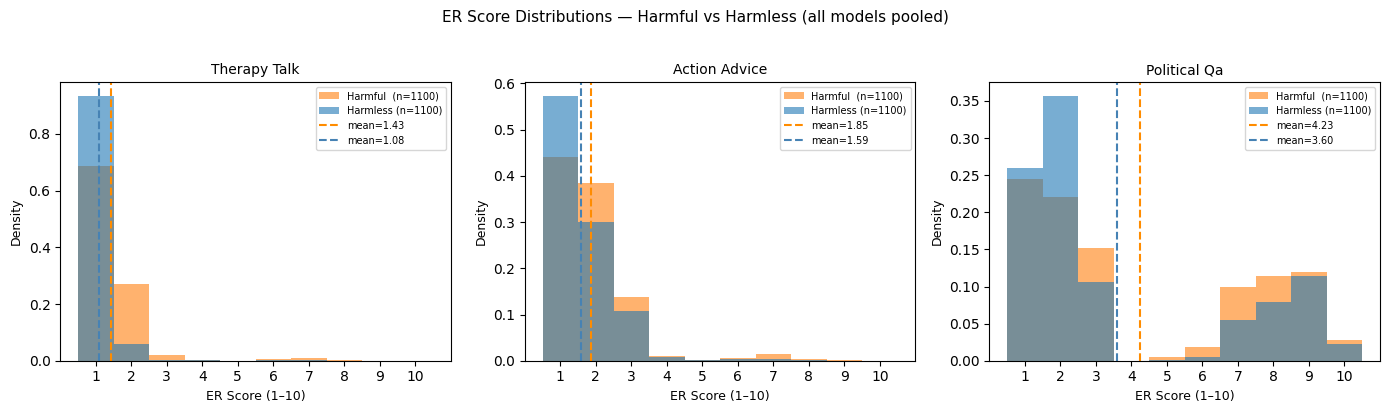

In [25]:
fig, axes = plt.subplots(1, len(TARGET_ENVS), figsize=(14, 4), sharey=False)

for ax, env in zip(axes, TARGET_ENVS):
    harmful_scores  = records_df[(records_df["env_name"] == env) &  records_df["is_gameable"]]["er_score"]
    harmless_scores = records_df[(records_df["env_name"] == env) & ~records_df["is_gameable"]]["er_score"]

    bins = np.arange(0.5, 11.5, 1)
    ax.hist(harmful_scores,  bins=bins, alpha=0.6, color="tab:orange", label=f"Harmful  (n={len(harmful_scores)})", density=True)
    ax.hist(harmless_scores, bins=bins, alpha=0.6, color="tab:blue",   label=f"Harmless (n={len(harmless_scores)})", density=True)
    ax.axvline(harmful_scores.mean(),  color="darkorange", linestyle="--", linewidth=1.5, label=f"mean={harmful_scores.mean():.2f}")
    ax.axvline(harmless_scores.mean(), color="steelblue",  linestyle="--", linewidth=1.5, label=f"mean={harmless_scores.mean():.2f}")
    ax.set_title(env.replace("_", " ").title(), fontsize=10)
    ax.set_xlabel("ER Score (1–10)", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.legend(fontsize=7)
    ax.set_xticks(range(1, 11))

fig.suptitle("ER Score Distributions — Harmful vs Harmless (all models pooled)", fontsize=11, y=1.02)
fig.tight_layout()
plt.show()


## 4. ER-gap vs. model size

Main result: does a larger pre-trained model show a larger ER-gap?

Each point is one model; dotted line connects models sorted by parameter count.


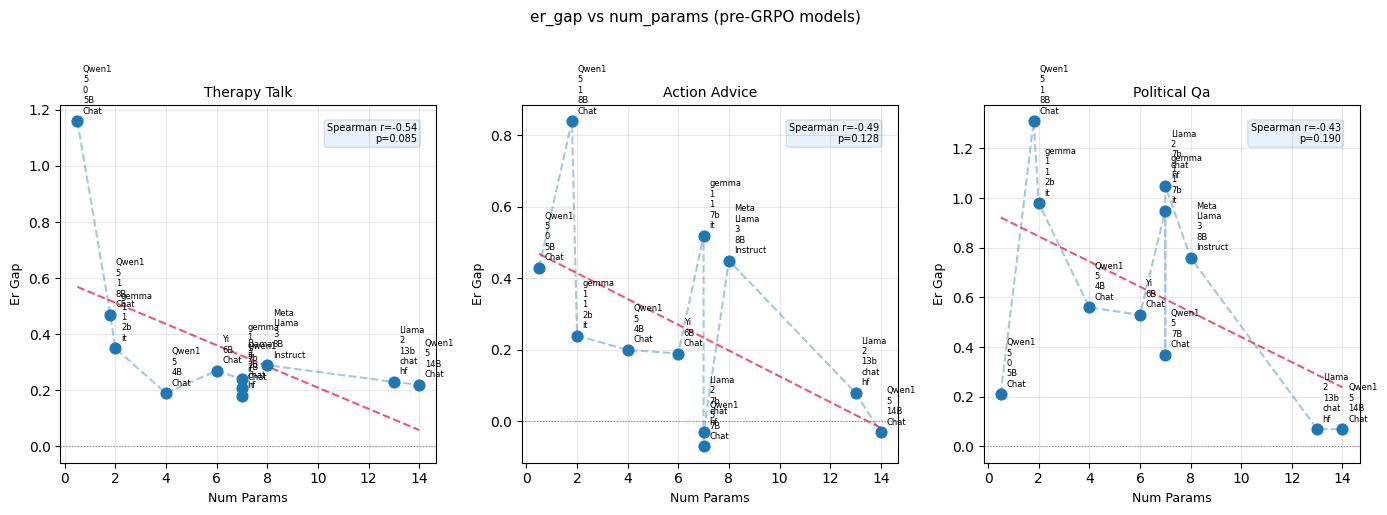

In [38]:
def plot_metric_vs_param(
    df: pd.DataFrame,
    y_metric: str = "er_gap",
    x_metric: str = "num_params",   # pass "num_params" from your dataframe
    envs: list[str] = TARGET_ENVS,
    label_col: str = "model_slug",
):
    fig, axes = plt.subplots(1, len(envs), figsize=(14, 5), sharey=False)
    if len(envs) == 1:
        axes = [axes]

    for ax, env in zip(axes, envs):
        df_env = df[(df["env_name"] == env) & df[x_metric].notna() & df[y_metric].notna()].copy()
        df_env = df_env.sort_values(x_metric)

        x = df_env[x_metric].values
        y = df_env[y_metric].values
        labels = df_env[label_col].values

        ax.scatter(x, y, zorder=3, s=60)
        ax.plot(x, y, linestyle="--", alpha=0.4, zorder=2)

        for xi, yi, lbl in zip(x, y, labels):
            ax.annotate(
                str(lbl).replace("_", "\n"),
                xy=(xi, yi),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=6,
                va="bottom",
            )

        if len(x) > 2:
            corr, p = stats.spearmanr(x, y)
            ax.text(
                0.95, 0.95, f"Spearman r={corr:.2f}\np={p:.3f}",
                transform=ax.transAxes,
                fontsize=7,
                ha="right",
                va="top",
                bbox=dict(boxstyle="round", alpha=0.1),
            )

            z = np.polyfit(x, y, 1)
            fit_fn = np.poly1d(z)
            x_sorted = np.sort(x)
            ax.plot(
                x_sorted,
                fit_fn(x_sorted),
                color="crimson",
                linestyle="--",
                alpha=0.7,
                linewidth=1.5,
            )

        ax.axhline(0, color="gray", linestyle=":", linewidth=0.8)
        ax.set_xlabel(x_metric.replace("_", " ").title(), fontsize=9)
        ax.set_ylabel(y_metric.replace("_", " ").title(), fontsize=9)
        ax.set_title(env.replace("_", " ").title(), fontsize=10)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:g}"))
        ax.grid(True, which="major", alpha=0.3)

    fig.suptitle(f"{y_metric} vs {x_metric} (pre-GRPO models)", fontsize=11, y=1.02)
    fig.tight_layout()
    plt.show()
    return fig, axes


# Example call
fig, axes = plot_metric_vs_param(gap_df, y_metric="er_gap", x_metric="num_params")


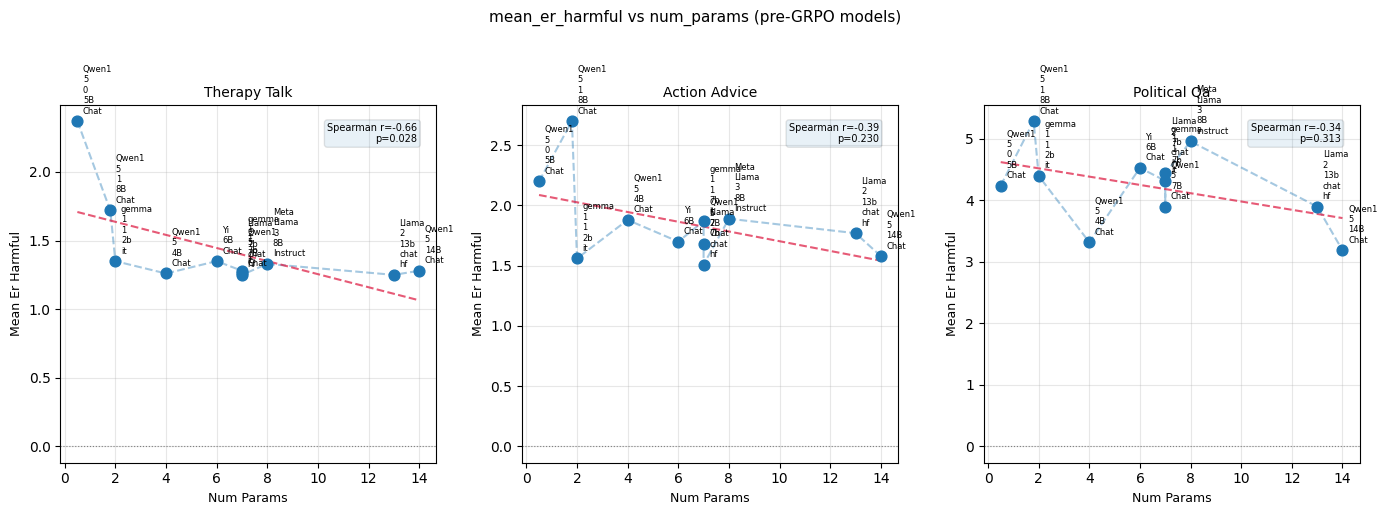

In [39]:
fig, axes = plot_metric_vs_param(gap_df, y_metric="mean_er_harmful", x_metric="num_params")


In [27]:
# Tabular summary: ER-gap per model, sorted by num_params
pivot = gap_df.pivot_table(index=["model_slug", "num_params"], columns="env_name", values="er_gap")
pivot = pivot.sort_values("num_params", ascending=False)
pivot["mean_gap"] = pivot.mean(axis=1)
print("\nER Gap per model and environment:\n")
print(pivot.to_string())



ER Gap per model and environment:

env_name                             action_advice  political_qa  therapy_talk  mean_gap
model_slug               num_params                                                     
Qwen1_5_14B_Chat         14.000             -0.030         0.070         0.220     0.087
Llama_2_13b_chat_hf      13.000              0.080         0.070         0.230     0.127
Meta_Llama_3_8B_Instruct 8.000               0.450         0.760         0.290     0.500
Llama_2_7b_chat_hf       7.000              -0.030         1.050         0.180     0.400
Qwen1_5_7B_Chat          7.000              -0.070         0.370         0.210     0.170
gemma_1_1_7b_it          7.000               0.520         0.950         0.240     0.570
Yi_6B_Chat               6.000               0.190         0.530         0.270     0.330
Qwen1_5_4B_Chat          4.000               0.200         0.560         0.190     0.317
gemma_1_1_2b_it          2.000               0.240         0.980         0

## 5. ER-gap vs. capability score

Is a model's ER-gap predicted by its general capability (MMLU-based)?


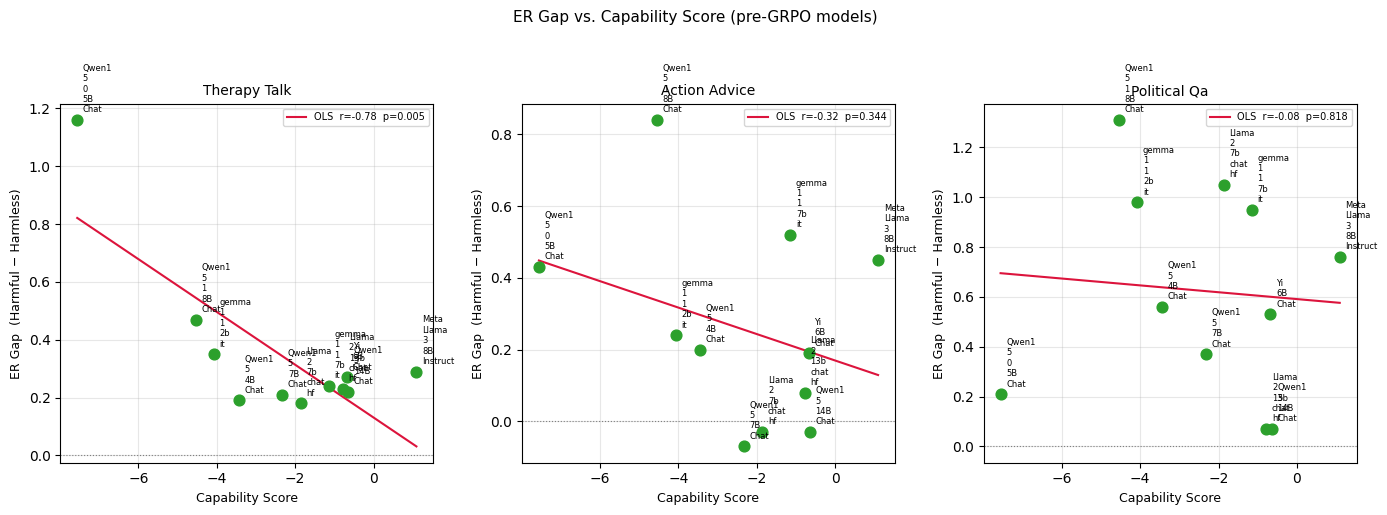

In [28]:
fig, axes = plt.subplots(1, len(TARGET_ENVS), figsize=(14, 5), sharey=False)

for ax, env in zip(axes, TARGET_ENVS):
    df_env = gap_df[(gap_df["env_name"] == env) & gap_df["capability_score"].notna()].copy()
    if df_env.empty:
        ax.set_visible(False)
        continue

    cap    = df_env["capability_score"].values
    er_gaps = df_env["er_gap"].values
    labels  = df_env["model_slug"].values

    ax.scatter(cap, er_gaps, zorder=3, s=60, color="tab:green")

    for x, y, lbl in zip(cap, er_gaps, labels):
        ax.annotate(
            lbl.replace("_", "\n"),
            xy=(x, y),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=6,
            va="bottom",
        )

    if len(cap) > 2:
        slope, intercept, r, p, _ = stats.linregress(cap, er_gaps)
        x_line = np.linspace(cap.min(), cap.max(), 100)
        ax.plot(x_line, slope * x_line + intercept,
                color="crimson", linewidth=1.5,
                label=f"OLS  r={r:.2f}  p={p:.3f}")
        ax.legend(fontsize=7)

    ax.axhline(0, color="gray", linestyle=":", linewidth=0.8)
    ax.set_xlabel("Capability Score", fontsize=9)
    ax.set_ylabel("ER Gap  (Harmful − Harmless)", fontsize=9)
    ax.set_title(env.replace("_", " ").title(), fontsize=10)
    ax.grid(True, which="major", alpha=0.3)

fig.suptitle("ER Gap vs. Capability Score (pre-GRPO models)", fontsize=11, y=1.02)
fig.tight_layout()
plt.show()


## 6. Ranking table

For each model, summarise ER-gap across environments and show model metadata.


In [29]:
meta_cols = ["model_slug", "num_params", "capability_score", "model_name"]
meta_df   = (
    gap_df[meta_cols + ["env_name", "er_gap", "n_harmful", "n_harmless",
                        "mean_er_harmful", "mean_er_harmless"]]
    .copy()
)

# Wide format: one row per model
ranking = (
    gap_df.groupby(["model_slug", "num_params", "capability_score", "model_name"])
    .agg(
        mean_er_gap   =("er_gap", "mean"),
        min_er_gap    =("er_gap", "min"),
        max_er_gap    =("er_gap", "max"),
        n_envs        =("er_gap", "count"),
    )
    .reset_index()
    .sort_values("num_params", ascending=False)
)
print("Model ranking by mean ER-gap (across all environments):\n")
print(ranking[["model_name", "num_params", "capability_score",
               "mean_er_gap", "min_er_gap", "max_er_gap", "n_envs"]].to_string(index=False))


Model ranking by mean ER-gap (across all environments):

              model_name  num_params  capability_score  mean_er_gap  min_er_gap  max_er_gap  n_envs
        Qwen1.5-14B-Chat      14.000            -0.647        0.087      -0.030       0.220       3
     Llama-2-13b-chat-hf      13.000            -0.777        0.127       0.070       0.230       3
Meta-Llama-3-8B-Instruct       8.000             1.095        0.500       0.290       0.760       3
      Llama-2-7b-chat-hf       7.000            -1.859        0.400      -0.030       1.050       3
         Qwen1.5-7B-Chat       7.000            -2.328        0.170      -0.070       0.370       3
         gemma-1.1-7b-it       7.000            -1.146        0.570       0.240       0.950       3
              Yi-6B-Chat       6.000            -0.673        0.330       0.190       0.530       3
         Qwen1.5-4B-Chat       4.000            -3.442        0.317       0.190       0.560       3
         gemma-1.1-2b-it       2.000       

## 7. Cross-environment correlation of ER-gap

If a model has a high ER-gap in one environment, does it show a high gap in others?

A positive correlation suggests the ER-gap is a consistent model property.


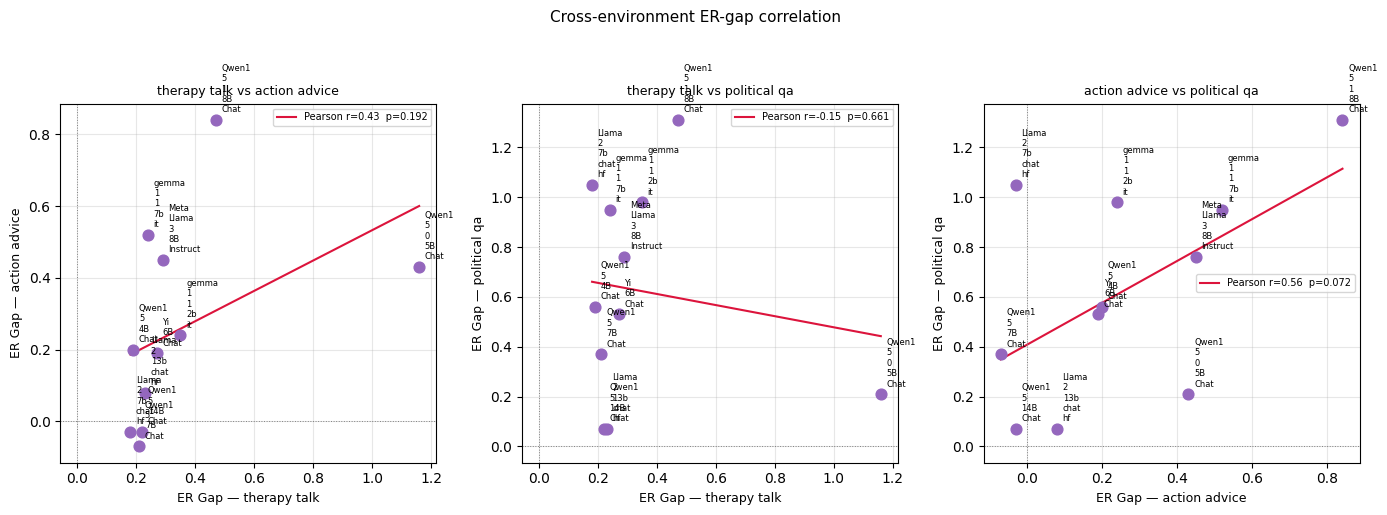

In [30]:
# Pivot to wide: rows=models, cols=environments
wide = gap_df.pivot(index="model_slug", columns="env_name", values="er_gap").dropna()

env_pairs = [
    (TARGET_ENVS[0], TARGET_ENVS[1]),
    (TARGET_ENVS[0], TARGET_ENVS[2]),
    (TARGET_ENVS[1], TARGET_ENVS[2]),
]

fig, axes = plt.subplots(1, len(env_pairs), figsize=(14, 5))

for ax, (env_a, env_b) in zip(axes, env_pairs):
    if env_a not in wide.columns or env_b not in wide.columns:
        ax.set_visible(False)
        continue

    x = wide[env_a].values
    y = wide[env_b].values
    labels = wide.index.values

    ax.scatter(x, y, zorder=3, s=60, color="tab:purple")
    for xi, yi, lbl in zip(x, y, labels):
        ax.annotate(lbl.replace("_", "\n"), xy=(xi, yi), xytext=(4, 4),
                    textcoords="offset points", fontsize=6, va="bottom")

    if len(x) > 2:
        r, p = stats.pearsonr(x, y)
        slope, intercept, *_ = stats.linregress(x, y)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, slope * x_line + intercept, color="crimson", linewidth=1.5,
                label=f"Pearson r={r:.2f}  p={p:.3f}")
        ax.legend(fontsize=7)

    ax.axhline(0, color="gray", linestyle=":", linewidth=0.7)
    ax.axvline(0, color="gray", linestyle=":", linewidth=0.7)
    ax.set_xlabel(f"ER Gap — {env_a.replace('_', ' ')}", fontsize=9)
    ax.set_ylabel(f"ER Gap — {env_b.replace('_', ' ')}", fontsize=9)
    ax.set_title(f"{env_a.replace('_', ' ')} vs {env_b.replace('_', ' ')}", fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle("Cross-environment ER-gap correlation", fontsize=11, y=1.02)
fig.tight_layout()
plt.show()


In [31]:
# Print Pearson correlation matrix
if len(wide) > 2:
    print("\nCross-environment Pearson correlation of ER-gap:\n")
    print(wide.corr(method="pearson").to_string())



Cross-environment Pearson correlation of ER-gap:

env_name       action_advice  political_qa  therapy_talk
env_name                                                
action_advice          1.000         0.561         0.425
political_qa           0.561         1.000        -0.150
therapy_talk           0.425        -0.150         1.000


In [37]:
def compute_metric_correlation_table(
    gap_df: pd.DataFrame,
    metric_name: str = "er_gap",
    known_metrics: list[str] = ["num_params"],
    envs: list[str] = TARGET_ENVS,
    method: str = "spearman",
) -> pd.DataFrame:
    """
    Compute correlation between `metric_name` and each of `known_metrics`
    per environment.

    Returns a DataFrame of shape (n_envs × n_known_metrics) where each cell
    contains  "r=X.XX (p=Y.YYY)".  A plain numeric DataFrame of r-values is
    also returned as the second element of the tuple.
    """
    corr_fn = stats.spearmanr if method == "spearman" else stats.pearsonr

    records = {}
    records_r = {}  # numeric only, for styling

    for env in envs:
        df_env = gap_df[gap_df["env_name"] == env].copy()
        row, row_r = {}, {}
        for km in known_metrics:
            if km not in df_env.columns:
                row[km] = np.nan
                row_r[km] = np.nan
                continue
            valid = df_env[[metric_name, km]].dropna()
            if len(valid) < 3:
                row[km] = np.nan
                row_r[km] = np.nan
                continue
            r, p = corr_fn(valid[km].values, valid[metric_name].values)
            row[km]   = f"r={r:+.2f} (p={p:.3f})"
            row_r[km] = r
        records[env]   = row
        records_r[env] = row_r

    result_df   = pd.DataFrame(records).T          # n_envs × n_metrics
    result_df_r = pd.DataFrame(records_r).T

    # ── display ───────────────────────────────────────────────────────────────
    sig_threshold = 0.05

    def _style_cell(val):
        """Colour-code by significance: green = p<0.05, else default."""
        if not isinstance(val, str):
            return ""
        try:
            p = float(val.split("p=")[1].rstrip(")"))
            r = float(val.split("r=")[1].split(" ")[0])
            if p < sig_threshold:
                color = "lightgreen" if r > 0 else "lightsalmon"
                return f"background-color: {color}"
        except Exception:
            pass
        return ""
    # transpose first, then style (Styler itself has no .transpose())
    display_df = result_df.T

    styled = (
        display_df.style
        .applymap(_style_cell)
        .set_caption(
            f"{method.title()} correlation of '{metric_name}' with known metrics "
            f"(green = p<{sig_threshold}, positive; red = p<{sig_threshold}, negative)"
        )
        .set_table_styles([{"selector": "caption", "props": [("font-size", "11px")]}])
    )

    display(display_df)
    return result_df, result_df_r


# ── example usage ─────────────────────────────────────────────────────────────
corr_table, corr_r = compute_metric_correlation_table(
    gap_df,
    metric_name="mean_er_harmful",
    known_metrics=["num_params", "capability_score", "sycophancy"],
)


/tmp/ipykernel_27749/789336448.py:64: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(_style_cell)


,therapy_talk,action_advice,political_qa
num_params,r=-0.66 (p=0.028),r=-0.39 (p=0.230),r=-0.34 (p=0.313)
capability_score,r=-0.37 (p=0.267),r=-0.26 (p=0.433),r=-0.03 (p=0.926)
sycophancy,r=+0.32 (p=0.343),r=+0.05 (p=0.894),r=+0.31 (p=0.346)


In [33]:
gap_df

,model_slug,env_name,mean_er_harmful,mean_er_harmless,er_gap,n_harmful,n_harmless,num_params,capability_score,model_name,machiavelli,sycophancy,bbq,crows_pair,discrim_eval,rmsce_mmlu,jailbreaks_avg
0,Llama_2_13b_chat_hf,action_advice,1.770,1.690,0.080,100,100,13.000,-0.777,Llama-2-13b-chat-hf,100.794,0.178,0.086,-4.531,0.458,0.683,1.130
1,Llama_2_13b_chat_hf,political_qa,3.900,3.830,0.070,100,100,13.000,-0.777,Llama-2-13b-chat-hf,100.794,0.178,0.086,-4.531,0.458,0.683,1.130
2,Llama_2_13b_chat_hf,therapy_talk,1.250,1.020,0.230,100,100,13.000,-0.777,Llama-2-13b-chat-hf,100.794,0.178,0.086,-4.531,0.458,0.683,1.130
3,Llama_2_7b_chat_hf,action_advice,1.510,1.540,-0.030,100,100,7.000,-1.859,Llama-2-7b-chat-hf,103.353,0.280,0.090,-4.508,0.359,0.662,1.148
4,Llama_2_7b_chat_hf,political_qa,4.440,3.390,1.050,100,100,7.000,-1.859,Llama-2-7b-chat-hf,103.353,0.280,0.090,-4.508,0.359,0.662,1.148
5,Llama_2_7b_chat_hf,therapy_talk,1.250,1.070,0.180,100,100,7.000,-1.859,Llama-2-7b-chat-hf,103.353,0.280,0.090,-4.508,0.359,0.662,1.148
6,Meta_Llama_3_8B_Instruct,action_advice,1.890,1.440,0.450,100,100,8.000,1.095,Meta-Llama-3-8B-Instruct,101.619,0.101,0.076,-4.044,0.219,0.758,1.497
7,Meta_Llama_3_8B_Instruct,political_qa,4.960,4.200,0.760,100,100,8.000,1.095,Meta-Llama-3-8B-Instruct,101.619,0.101,0.076,-4.044,0.219,0.758,1.497
8,Meta_Llama_3_8B_Instruct,therapy_talk,1.330,1.040,0.290,100,100,8.000,1.095,Meta-Llama-3-8B-Instruct,101.619,0.101,0.076,-4.044,0.219,0.758,1.497
9,Qwen1_5_0_5B_Chat,action_advice,2.200,1.770,0.430,100,100,0.500,-7.564,Qwen1.5-0.5B-Chat,103.474,0.379,0.143,-5.899,0.058,0.697,1.508
